Text(0, 0.5, 'x2')

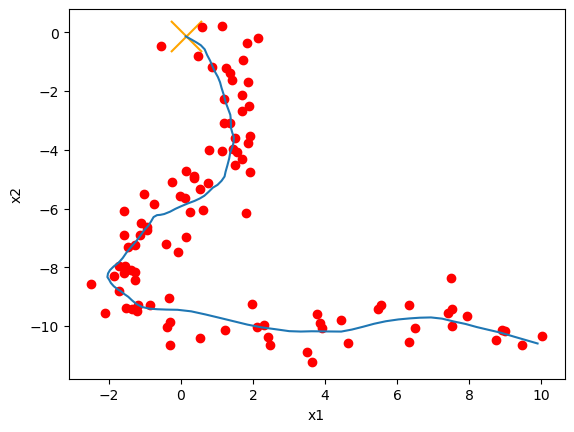

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

with open("car_track.json") as fp:
    jsondata = json.load(fp)
    states = np.array(jsondata["X"]).T
    observations = np.array(jsondata["Y"]).T
    steps = states.shape[0]

plt.scatter(
    states[0, 0], states[0, 1], marker="x", color="orange", s=500, label="Start"
)
plt.scatter(observations[:, 0], observations[:, 1], label="Observed", color="red")
plt.plot(states[:, 0], states[:, 1], label="True")
plt.xlabel("x1")
plt.ylabel("x2")

In [2]:
q = 1.0  # process_noise
dt = 0.1  # time_step
s = 0.5  # observation_noise

M = 4  # State dimension
N = 2  # Observation dimension

A = np.array(
    [[1, 0, dt, 0], [0, 1, 0, dt], [0, 0, 1, 0], [0, 0, 0, 1]]
)  # transition_matrix
Q = q * np.array(
    [
        [dt**3 / 3, 0, dt**2 / 2, 0],
        [0, dt**3 / 3, 0, dt**2 / 2],
        [dt**2 / 2, 0, dt, 0],
        [0, dt**2 / 2, 0, dt],
    ]
)  # process_noise_covariance

H = np.array([[1, 0, 0, 0], [0, 1, 0, 0]])  # observation_matrix

R = np.array([[s**2, 0], [0, s**2]])  # observation_noise_covariance

x_0 = np.array([0.0, 0.0, 1.0, -1.0])  # initial_state_mean

m_0 = x_0  # initial_state_mean
P_0 = np.array(
    [[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 1, 0], [0, 0, 0, 1]], dtype=float
)  # initial_state_covariance

In [3]:
from state_space_practice.kalman import kalman_filter

filtered_mean, filtered_cov, marginal_log_likelihood = (
    kalman_filter(
        init_mean=m_0,
        init_cov=P_0,
        obs=observations,
        transition_matrix=A,
        process_cov=Q,
        measurement_matrix=H,
        measurement_cov=R,
    )
)


def rmse(x, y):
    """Computes the RMSE between x and y along all their dimensions, x and y must have the same dimensions.

    Parameters
    ----------
    x : (L,...) array_like
        Initial mean of the state
    y : (L, ...) array_like
        Initial covariance of the state

    Returns
    -------
    out : float
        The RMSE
    """
    return np.sqrt(np.mean(np.sum(np.square(x - y), axis=-1)))


rmse_raw = rmse(states[:, :2], observations)
rmse_kf = rmse(filtered_mean[:, :2], states[:, :2])
print(f"RAW RMSE: {rmse_raw}")
print(f"KF RMSE: {rmse_kf}")

RAW RMSE: 0.7679855237247215
KF RMSE: 0.4253825545310974


Text(0, 0.5, 'x2')

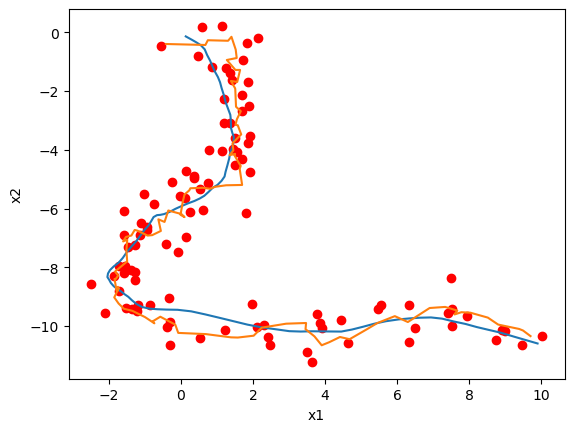

In [4]:
plt.scatter(observations[:, 0], observations[:, 1], label="Observed", color="red")
plt.plot(states[:, 0], states[:, 1], label="True")
plt.plot(filtered_mean[:, 0], filtered_mean[:, 1])
plt.xlabel("x1")
plt.ylabel("x2")

In [5]:
from state_space_practice.kalman import kalman_smoother


smoother_mean, smoother_cov, smoother_cross_cov, marginal_log_likelihood = (
    kalman_smoother(
        init_mean=m_0,
        init_cov=P_0,
        obs=observations,
        transition_matrix=A,
        process_cov=Q,
        measurement_matrix=H,
        measurement_cov=R,
    )
)

RTS RMSE: 0.26497116684913635


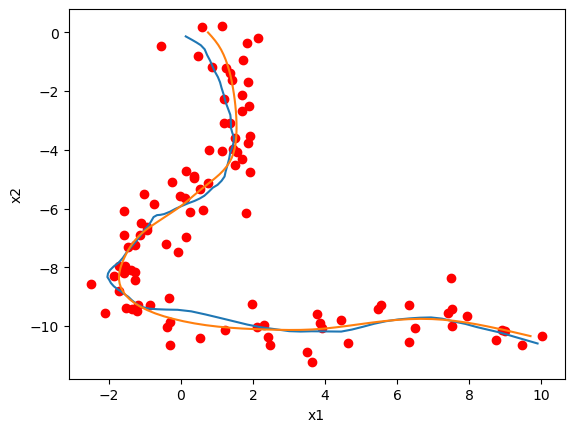

In [6]:
plt.scatter(observations[:, 0], observations[:, 1], label="Observed", color="red")
plt.plot(states[:, 0], states[:, 1], label="True")
# plt.plot(filtered_mean[:, 0], filtered_mean[:, 1])
plt.plot(smoother_mean[:, 0], smoother_mean[:, 1])
plt.xlabel("x1")
plt.ylabel("x2")

rmse_rts = rmse(states[:, :2], smoother_mean[:, :2])
print(f"RTS RMSE: {rmse_rts}")

In [7]:
import scipy.linalg


def kalman_filter2(m_0, P_0, A, Q, H, R, observations):
    M = m_0.shape[-1]
    steps, N = observations.shape

    kf_m = np.empty((steps, M))
    kf_P = np.empty((steps, M, M))

    m = m_0
    P = P_0

    for i in range(steps):
        y = observations[i]
        m = A @ m
        P = A @ P @ A.T + Q

        S = H @ P @ H.T + R
        # More efficient and stable way of computing K = P @ H.T @ linalg.inv(S)
        # This also leverages the fact that S is known to be a positive definite matrix (assume_a="pos")
        K = scipy.linalg.solve(S.T, H @ P, assume_a="pos").T

        m = m + K @ (y - H @ m)
        P = P - K @ S @ K.T

        kf_m[i] = m
        kf_P[i] = P
    return kf_m, kf_P


def rts_smoother(kf_m, kf_P, A, Q):
    steps, M = kf_m.shape

    rts_m = np.empty((steps, M))
    rts_P = np.empty((steps, M, M))

    m = kf_m[-1]
    P = kf_P[-1]

    rts_m[-1] = m
    rts_P[-1] = P

    for i in range(steps - 2, -1, -1):
        filtered_m = kf_m[i]
        filtered_P = kf_P[i]

        mp = A @ filtered_m
        Pp = A @ filtered_P @ A.T + Q

        # More efficient and stable way of computing Gk = filtered_P @ A.T @ linalg.inv(Pp)
        # This also leverages the fact that Pp is known to be a positive definite matrix (assume_a="pos")
        Gk = scipy.linalg.solve(Pp, A @ filtered_P, assume_a="pos").T

        m = filtered_m + Gk @ (m - mp)
        P = filtered_P + Gk @ (P - Pp) @ Gk.T

        rts_m[i] = m
        rts_P[i] = P

    return rts_m, rts_P


kf_m, kf_P = kalman_filter2(m_0, P_0, A, Q, H, R, observations)
rts_m, rts_P = rts_smoother(kf_m, kf_P, A, Q)

In [8]:
np.allclose(kf_m, filtered_mean, atol=1e-5), np.allclose(kf_P, filtered_cov, atol=1e-5)

(True, True)

In [9]:
np.allclose(rts_m, smoother_mean, atol=1e-5), np.allclose(
    rts_P, smoother_cov, atol=1e-5
)

(True, True)

In [10]:
smoother_cross_cov.shape

(99, 4, 4)

Iteration 0: Log likelihood = -195.90
Iteration 1: Log likelihood = -185.43(change: 10.47)
Iteration 2: Log likelihood = -184.80(change: 0.63)
Iteration 3: Log likelihood = -184.70(change: 0.11)
Iteration 4: Log likelihood = -184.71(change: -0.02)
Iteration 5: Log likelihood = -184.79(change: -0.07)
Iteration 6: Log likelihood = -184.86(change: -0.08)
Iteration 7: Log likelihood = -184.99(change: -0.12)
Iteration 8: Log likelihood = -185.07(change: -0.09)
Iteration 9: Log likelihood = -185.51(change: -0.44)
Iteration 10: Log likelihood = -188.61(change: -3.09)
Iteration 11: Log likelihood = nan(change: nan)
Iteration 12: Log likelihood = nan(change: nan)
Iteration 13: Log likelihood = nan(change: nan)
Iteration 14: Log likelihood = nan(change: nan)
Iteration 15: Log likelihood = nan(change: nan)
Iteration 16: Log likelihood = nan(change: nan)
Iteration 17: Log likelihood = nan(change: nan)
Iteration 18: Log likelihood = nan(change: nan)
Iteration 19: Log likelihood = nan(change: nan)


Text(0, 0.5, 'Log likelihood')

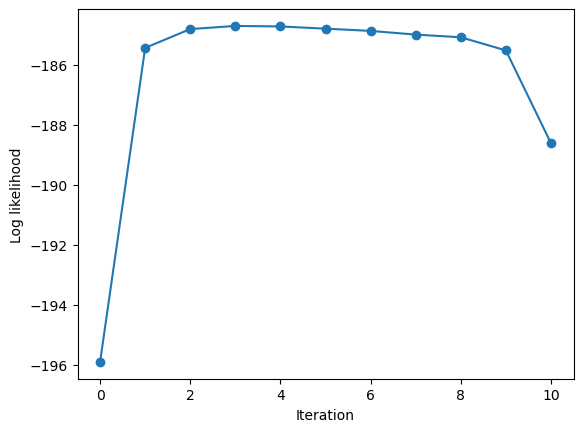

In [11]:
from state_space_practice.kalman import kalman_maximization_step
import jax.numpy as jnp

marginal_log_likelihood = []
init_mean = jnp.asarray(m_0, dtype=jnp.float32)
init_cov = jnp.asarray(P_0, dtype=jnp.float32)
obs = jnp.asarray(observations, dtype=jnp.float32)
transition_matrix = jnp.asarray(A, dtype=jnp.float32)
process_cov = jnp.asarray(Q, dtype=jnp.float32)
measurement_matrix = jnp.asarray(H, dtype=jnp.float32)
measurement_cov = jnp.asarray(R, dtype=jnp.float32)

for iter in range(20):
    smoother_mean, smoother_cov, smoother_cross_cov, new_marginal_log_likelihood = (
        kalman_smoother(
            init_mean=init_mean,
            init_cov=init_cov,
            obs=obs,
            transition_matrix=transition_matrix,
            process_cov=process_cov,
            measurement_matrix=measurement_matrix,
            measurement_cov=measurement_cov,
        )
    )
    marginal_log_likelihood.append(new_marginal_log_likelihood)
    (
        transition_matrix,
        measurement_matrix,
        process_cov,
        measurement_cov,
        init_mean,
        init_cov,
    ) = kalman_maximization_step(
        obs=observations,
        smoother_mean=smoother_mean,
        smoother_cov=smoother_cov,
        smoother_cross_cov=smoother_cross_cov,
    )

    if iter > 0:
        print(
            f"Iteration {iter}: Log likelihood = {marginal_log_likelihood[-1]:.2f}"
            f"(change: {marginal_log_likelihood[-1] - marginal_log_likelihood[-2]:.2f})"
        )
    else:
        print(f"Iteration {iter}: Log likelihood = {marginal_log_likelihood[-1]:.2f}")
    if (
        iter > 1
        and np.abs(marginal_log_likelihood[-1] - marginal_log_likelihood[-2]) < 1e-3
    ):
        break

plt.plot(marginal_log_likelihood)
plt.scatter(range(len(marginal_log_likelihood)), marginal_log_likelihood)
plt.xlabel("Iteration")
plt.ylabel("Log likelihood")

In [12]:
%debug

ERROR:root:No traceback has been produced, nothing to debug.


In [13]:
jnp.asarray(R, dtype=jnp.float32)

Array([[0.25, 0.  ],
       [0.  , 0.25]], dtype=float32)

In [14]:
measurement_cov

Array([[nan, nan],
       [nan, nan]], dtype=float32)

Iteration 0: Log likelihood = -195.88
Iteration 1: Log likelihood = -185.11(change: 10.78)
Iteration 2: Log likelihood = -184.08(change: 1.02)
Iteration 3: Log likelihood = -183.57(change: 0.52)
Iteration 4: Log likelihood = -183.21(change: 0.36)
Iteration 5: Log likelihood = -182.89(change: 0.32)
Iteration 6: Log likelihood = -182.73(change: 0.15)
Iteration 7: Log likelihood = -182.66(change: 0.07)
Iteration 8: Log likelihood = nan(change: nan)
Iteration 9: Log likelihood = nan(change: nan)
Iteration 10: Log likelihood = nan(change: nan)
Iteration 11: Log likelihood = nan(change: nan)
Iteration 12: Log likelihood = nan(change: nan)
Iteration 13: Log likelihood = nan(change: nan)
Iteration 14: Log likelihood = nan(change: nan)
Iteration 15: Log likelihood = nan(change: nan)
Iteration 16: Log likelihood = nan(change: nan)
Iteration 17: Log likelihood = nan(change: nan)
Iteration 18: Log likelihood = nan(change: nan)
Iteration 19: Log likelihood = nan(change: nan)


Text(0, 0.5, 'Log likelihood')

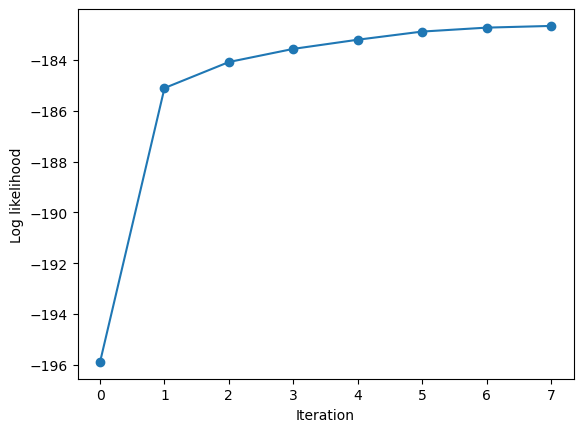

In [15]:
from state_space_practice.kalman import kalman_maximization_step
import jax.numpy as jnp
from dynamax.linear_gaussian_ssm.inference import (
    ParamsLGSSM,
    ParamsLGSSMInitial,
    ParamsLGSSMDynamics,
    ParamsLGSSMEmissions,
)
from dynamax.linear_gaussian_ssm.inference import lgssm_smoother
from dynamax.linear_gaussian_ssm import LinearGaussianSSM
import jax.numpy as jnp
import jax.random as jr

key = jr.PRNGKey(42)

lgssm = LinearGaussianSSM(
    state_dim=M,
    emission_dim=N,
    input_dim=0,
    has_dynamics_bias=True,
    has_emissions_bias=True,
)
params_lgssm, param_props = lgssm.initialize(
    initial_mean=jnp.asarray(m_0, dtype=jnp.float32),
    initial_covariance=jnp.asarray(P_0, dtype=jnp.float32),
    dynamics_weights=jnp.asarray(A, dtype=jnp.float32),
    dynamics_covariance=jnp.asarray(Q, dtype=jnp.float32),
    emission_weights=jnp.asarray(H, dtype=jnp.float32),
    emission_covariance=jnp.asarray(R, dtype=jnp.float32),
)

marginal_log_likelihood2 = []

for iter in range(20):

    posterior = lgssm_smoother(params_lgssm, obs)
    marginal_log_likelihood2.append(posterior.marginal_loglik)
    (
        transition_matrix,
        measurement_matrix,
        process_cov,
        measurement_cov,
        init_mean,
        init_cov,
    ) = kalman_maximization_step(
        obs=obs,
        smoother_mean=posterior.smoothed_means,
        smoother_cov=posterior.smoothed_covariances,
        smoother_cross_cov=posterior.smoothed_cross_covariances,
    )
    params_lgssm = ParamsLGSSM(
        initial=ParamsLGSSMInitial(mean=init_mean, cov=init_cov),
        dynamics=ParamsLGSSMDynamics(
            weights=transition_matrix,
            bias=params_lgssm.dynamics.bias,
            input_weights=params_lgssm.dynamics.input_weights,
            cov=process_cov,
        ),
        emissions=ParamsLGSSMEmissions(
            weights=measurement_matrix,
            bias=params_lgssm.emissions.bias,
            input_weights=params_lgssm.emissions.input_weights,
            cov=measurement_cov,
        ),
    )

    if iter > 0:
        print(
            f"Iteration {iter}: Log likelihood = {marginal_log_likelihood2[-1]:.2f}"
            f"(change: {marginal_log_likelihood2[-1] - marginal_log_likelihood2[-2]:.2f})"
        )
    else:
        print(f"Iteration {iter}: Log likelihood = {marginal_log_likelihood2[-1]:.2f}")
    if (
        iter > 1
        and np.abs(marginal_log_likelihood2[-1] - marginal_log_likelihood2[-2]) < 1e-3
    ):
        break

plt.plot(marginal_log_likelihood2)
plt.scatter(range(len(marginal_log_likelihood2)), marginal_log_likelihood2)
plt.xlabel("Iteration")
plt.ylabel("Log likelihood")

In [16]:
marginal_log_likelihood = []
init_mean = jnp.asarray(m_0, dtype=jnp.float32)
init_cov = jnp.asarray(P_0, dtype=jnp.float32)
obs = jnp.asarray(observations, dtype=jnp.float32)
transition_matrix = jnp.asarray(A, dtype=jnp.float32)
process_cov = jnp.asarray(Q, dtype=jnp.float32)
measurement_matrix = jnp.asarray(H, dtype=jnp.float32)
measurement_cov = jnp.asarray(R, dtype=jnp.float32)

smoother_mean, smoother_cov, smoother_cross_cov, new_marginal_log_likelihood = (
    kalman_smoother(
        init_mean=init_mean,
        init_cov=init_cov,
        obs=obs,
        transition_matrix=transition_matrix,
        process_cov=process_cov,
        measurement_matrix=measurement_matrix,
        measurement_cov=measurement_cov,
    )
)

(
    transition_matrix2,
    measurement_matrix2,
    process_cov2,
    measurement_cov2,
    init_mean2,
    init_cov2,
) = kalman_maximization_step(
    obs=observations,
    smoother_mean=smoother_mean,
    smoother_cov=smoother_cov,
    smoother_cross_cov=smoother_cross_cov,
)

In [17]:
(
    transition_matrix2,
    measurement_matrix2,
    process_cov2,
    measurement_cov2,
    init_mean2,
    init_cov2,
)

(Array([[ 9.9878180e-01, -8.3774218e-04,  9.9317402e-02,  1.6835516e-03],
        [-8.2671695e-04,  1.0002341e+00,  1.5024878e-03,  9.7502269e-02],
        [-2.4222746e-02, -1.6730130e-02,  9.8611820e-01,  3.3416126e-02],
        [-1.6438099e-02,  4.6146279e-03,  2.9713407e-02,  9.5057434e-01]],      dtype=float32),
 Array([[ 1.0010648e+00,  2.5370860e-04, -5.1122421e-04,  2.3806361e-04],
        [ 1.4076011e-03,  9.9932069e-01, -3.9735427e-03,  1.6558613e-03]],      dtype=float32),
 Array([[3.2428780e-04, 7.3982010e-06, 4.7998908e-03, 5.8838814e-05],
        [6.1651672e-06, 3.3045295e-04, 5.9185608e-05, 4.6787453e-03],
        [4.7995825e-03, 6.0418639e-05, 9.6028030e-02, 1.1569803e-03],
        [5.8838814e-05, 4.6787453e-03, 1.1569707e-03, 9.3634710e-02]],      dtype=float32),
 Array([[0.27834472, 0.0044397 ],
        [0.0044397 , 0.2918164 ]], dtype=float32),
 Array([ 0.7501303 , -0.00468814,  1.0344169 , -1.3495927 ], dtype=float32),
 Array([[ 0.05912006,  0.        , -0.08185932, 

In [18]:
smoother_mean2, smoother_cov2, smoother_cross_cov2, new_marginal_log_likelihood2 = (
    kalman_smoother(
        init_mean=init_mean,
        init_cov=init_cov,
        obs=obs,
        transition_matrix=transition_matrix2,
        process_cov=process_cov2,
        measurement_matrix=measurement_matrix2,
        measurement_cov=measurement_cov2,
    )
)

In [19]:
process_cov2

Array([[3.2428780e-04, 7.3982010e-06, 4.7998908e-03, 5.8838814e-05],
       [6.1651672e-06, 3.3045295e-04, 5.9185608e-05, 4.6787453e-03],
       [4.7995825e-03, 6.0418639e-05, 9.6028030e-02, 1.1569803e-03],
       [5.8838814e-05, 4.6787453e-03, 1.1569707e-03, 9.3634710e-02]],      dtype=float32)

In [20]:
process_cov2

Array([[3.2428780e-04, 7.3982010e-06, 4.7998908e-03, 5.8838814e-05],
       [6.1651672e-06, 3.3045295e-04, 5.9185608e-05, 4.6787453e-03],
       [4.7995825e-03, 6.0418639e-05, 9.6028030e-02, 1.1569803e-03],
       [5.8838814e-05, 4.6787453e-03, 1.1569707e-03, 9.3634710e-02]],      dtype=float32)

In [21]:
init_mean2

Array([ 0.7501303 , -0.00468814,  1.0344169 , -1.3495927 ], dtype=float32)

RTS RMSE: 0.26497116684913635


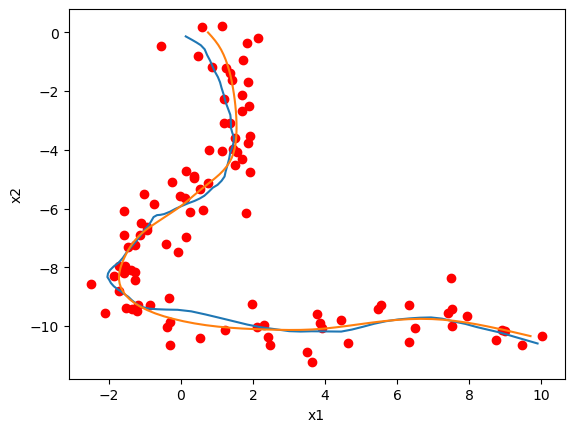

In [22]:
plt.scatter(observations[:, 0], observations[:, 1], label="Observed", color="red")
plt.plot(states[:, 0], states[:, 1], label="True")
# plt.plot(filtered_mean[:, 0], filtered_mean[:, 1])
plt.plot(smoother_mean[:, 0], smoother_mean[:, 1])
plt.xlabel("x1")
plt.ylabel("x2")

rmse_rts = rmse(states[:, :2], smoother_mean[:, :2])
print(f"RTS RMSE: {rmse_rts}")

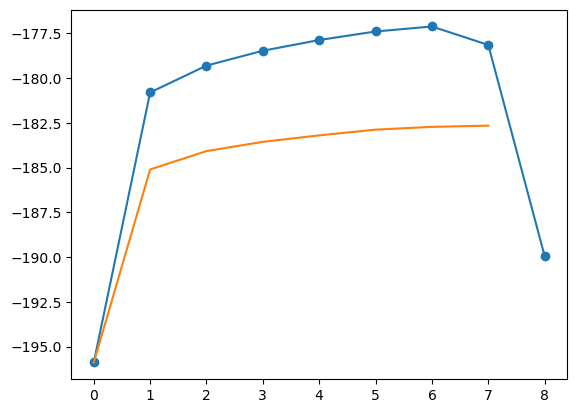

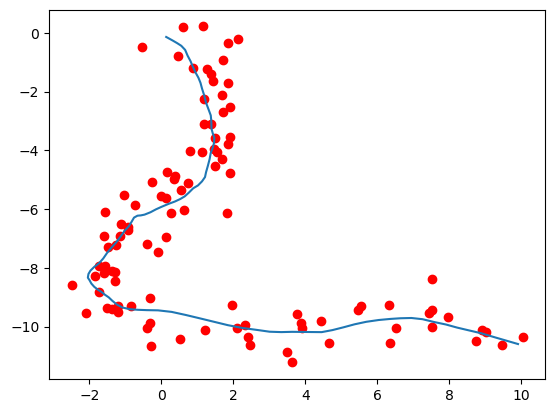

In [23]:
from dynamax.linear_gaussian_ssm import LinearGaussianSSM
import jax.numpy as jnp
import jax.random as jr

key = jr.PRNGKey(42)

lgssm = LinearGaussianSSM(
    state_dim=M,
    emission_dim=N,
    input_dim=0,
    has_dynamics_bias=True,
    has_emissions_bias=True,
)
params_lgssm, param_props = lgssm.initialize(
    initial_mean=jnp.asarray(m_0, dtype=jnp.float32),
    initial_covariance=jnp.asarray(P_0, dtype=jnp.float32),
    dynamics_weights=jnp.asarray(A, dtype=jnp.float32),
    dynamics_covariance=jnp.asarray(Q, dtype=jnp.float32),
    emission_weights=jnp.asarray(H, dtype=jnp.float32),
    emission_covariance=jnp.asarray(R, dtype=jnp.float32),
)
# params_lgssm, param_props = lgssm.initialize(key=key)

# lgssm_posterior = lgssm.filter(params_lgssm, jnp.asarray(observations))
new_param_set, ll = lgssm.fit_em(
    params=params_lgssm,
    props=param_props,
    emissions=jnp.asarray(observations),
    verbose=True,
    num_iters=200,
)
plt.plot(ll)
plt.scatter(range(len(ll)), ll)
plt.plot(marginal_log_likelihood2)

post_pred_means, post_pred_std = lgssm.posterior_predictive(
    new_param_set, jnp.asarray(observations)
)
plt.figure()
plt.scatter(observations[:, 0], observations[:, 1], label="Observed", color="red")
plt.plot(states[:, 0], states[:, 1], label="True")
plt.plot(post_pred_means[:, 0], post_pred_means[:, 1])

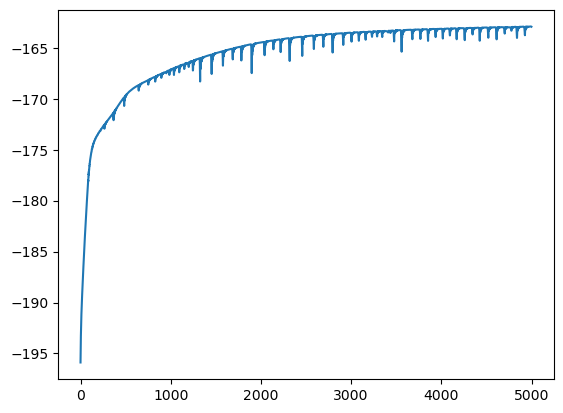

In [24]:
lgssm = LinearGaussianSSM(
    state_dim=M,
    emission_dim=N,
    input_dim=0,
    has_dynamics_bias=True,
    has_emissions_bias=True,
)
params_lgssm, param_props = lgssm.initialize(
    initial_mean=jnp.asarray(m_0, dtype=jnp.float32),
    initial_covariance=jnp.asarray(P_0, dtype=jnp.float32),
    dynamics_weights=jnp.asarray(A, dtype=jnp.float32),
    dynamics_covariance=jnp.asarray(Q, dtype=jnp.float32),
    emission_weights=jnp.asarray(H, dtype=jnp.float32),
    emission_covariance=jnp.asarray(R, dtype=jnp.float32),
)
# params_lgssm, param_props = lgssm.initialize(key=key)

new_param_set, ll = lgssm.fit_sgd(
    params=params_lgssm,
    props=param_props,
    emissions=jnp.asarray(observations),
    batch_size=100,
    num_epochs=5000,
)

plt.plot(-ll * observations.size)

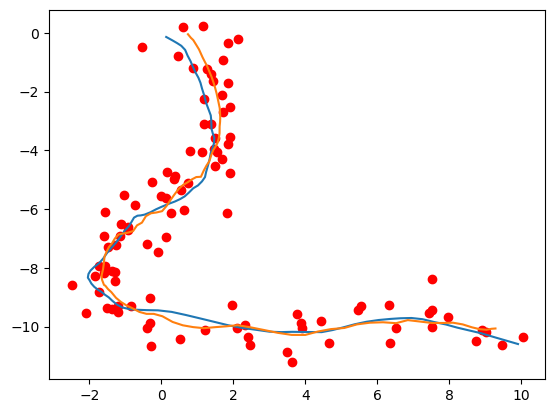

In [25]:
post_pred_means, post_pred_std = lgssm.posterior_predictive(new_param_set, jnp.asarray(observations))

plt.scatter(observations[:, 0], observations[:, 1], label="Observed", color="red")
plt.plot(states[:, 0], states[:, 1], label="True")
plt.plot(post_pred_means[:, 0], post_pred_means[:, 1])

In [26]:
from functools import partial
import jax

lgssm = LinearGaussianSSM(
    state_dim=M,
    emission_dim=N,
    input_dim=0,
    has_dynamics_bias=False,
    has_emissions_bias=False,
)
params_lgssm, param_props = lgssm.initialize(
    initial_mean=jnp.asarray(m_0, dtype=jnp.float32),
    initial_covariance=jnp.asarray(P_0, dtype=jnp.float32),
    dynamics_weights=jnp.asarray(A, dtype=jnp.float32),
    dynamics_covariance=jnp.asarray(Q, dtype=jnp.float32),
    emission_weights=jnp.asarray(H, dtype=jnp.float32),
    emission_covariance=jnp.asarray(R, dtype=jnp.float32),
)

posterior = lgssm.smoother(params_lgssm, jnp.asarray(observations))

# shorthand
Ex = posterior.smoothed_means
Exp = posterior.smoothed_means[:-1]
Exn = posterior.smoothed_means[1:]
Vx = posterior.smoothed_covariances
Vxp = posterior.smoothed_covariances[:-1]
Vxn = posterior.smoothed_covariances[1:]
Expxn = posterior.smoothed_cross_covariances

num_timesteps = observations.shape[0]
inputs = jnp.zeros((num_timesteps, 0))

inputs = jnp.concatenate((inputs, jnp.ones((num_timesteps, 1))), axis=1)
up = inputs[:-1]
u = inputs
y = observations

# expected sufficient statistics for the initial tfd.Distribution
Ex0 = posterior.smoothed_means[0]
Ex0x0T = posterior.smoothed_covariances[0] + jnp.outer(Ex0, Ex0)
init_stats = (Ex0, Ex0x0T, 1)

# expected sufficient statistics for the dynamics tfd.Distribution
# let zp[t] = [x[t], u[t]] for t = 0...T-2
# let xn[t] = x[t+1]          for t = 0...T-2
sum_zpzpT = jnp.block([[Exp.T @ Exp, Exp.T @ up], [up.T @ Exp, up.T @ up]])
sum_zpzpT = sum_zpzpT.at[: lgssm.state_dim, : lgssm.state_dim].add(Vxp.sum(0))
sum_zpxnT = jnp.block([[Expxn.sum(0)], [up.T @ Exn]])
sum_xnxnT = Vxn.sum(0) + Exn.T @ Exn
dynamics_stats = (sum_zpzpT, sum_zpxnT, sum_xnxnT, num_timesteps - 1)
dynamics_stats = (sum_zpzpT[:-1, :-1], sum_zpxnT[:-1, :], sum_xnxnT,
                    num_timesteps - 1)

# more expected sufficient statistics for the emissions
# let z[t] = [x[t], u[t]] for t = 0...T-1
sum_zzT = jnp.block([[Ex.T @ Ex, Ex.T @ u], [u.T @ Ex, u.T @ u]])
sum_zzT = sum_zzT.at[: lgssm.state_dim, : lgssm.state_dim].add(Vx.sum(0))
sum_zyT = jnp.block([[Ex.T @ y], [u.T @ y]])
sum_yyT = observations.T @ observations
emission_stats = (sum_zzT, sum_zyT, sum_yyT, num_timesteps)
emission_stats = (sum_zzT[:-1, :-1], sum_zyT[:-1, :], sum_yyT, num_timesteps)

batch_stats = (init_stats, dynamics_stats, emission_stats)


In [27]:
emission_stats

(Array([[ 1127.7708  , -1376.3969  ,   483.52322 ,   -64.49617 ],
        [-1376.3969  ,  5564.312   ,  -959.9456  ,   539.5663  ],
        [  483.52322 ,  -959.9456  ,   406.07837 ,    -9.364655],
        [  -64.49617 ,   539.5663  ,    -9.364655,   172.05862 ]],      dtype=float32),
 Array([[ 1128.3868 , -1375.9346 ],
        [-1375.8514 ,  5563.3086 ],
        [  483.61072,  -960.2651 ],
        [  -64.43182,   539.47736]], dtype=float32),
 array([[ 1156.84388165, -1374.94344044],
        [-1374.94344044,  5591.48971463]]),
 100)

In [28]:
from dynamax.utils.utils import ensure_array_has_batch_dim

emissions = jnp.asarray(observations)

inputs = None

batch_emissions = ensure_array_has_batch_dim(emissions, lgssm.emission_shape)
batch_inputs = ensure_array_has_batch_dim(inputs, lgssm.inputs_shape)


params = params_lgssm
batch_stats, lls = jax.vmap(partial(lgssm.e_step, params))(batch_emissions, batch_inputs)


In [29]:
stats = jax.tree.map(partial(jnp.sum, axis=0), batch_stats)
init_stats, dynamics_stats, emission_stats = stats

In [30]:
# Perform MLE estimation jointly
sum_x0, sum_x0x0T, N = init_stats
S = (sum_x0x0T - jnp.outer(sum_x0, sum_x0)) / N
m = sum_x0 / N

In [31]:
from dynamax.utils.utils import psd_solve

def fit_linear_regression(ExxT, ExyT, EyyT, N):
    # Solve a linear regression given sufficient statistics
    W = psd_solve(ExxT, ExyT).T
    Sigma = (EyyT - W @ ExyT - ExyT.T @ W.T + W @ ExxT @ W.T) / N
    return W, Sigma

FB, Q = fit_linear_regression(*dynamics_stats)
F = FB[:, : lgssm.state_dim]
B, b = (
    (FB[:, lgssm.state_dim : -1], FB[:, -1])
    if lgssm.has_dynamics_bias
    else (FB[:, lgssm.state_dim :], None)
)

In [32]:
dynamics_stats

(Array([[ 1033.4108   , -1275.9513   ,   454.68246  ,   -56.179184 ],
        [-1275.9513   ,  5457.229    ,  -929.36145  ,   530.5735   ],
        [  454.68246  ,  -929.36145  ,   396.82178  ,    -6.8322573],
        [  -56.179184 ,   530.5735   ,    -6.8322573,   170.80968  ]],      dtype=float32),
 Array([[ 1078.2849   , -1281.8984   ,   442.82077  ,   -62.760975 ],
        [-1370.3771   ,  5509.8975   ,  -959.1214   ,   522.8813   ],
        [  494.30786  ,  -930.02484  ,   395.6378   ,    -6.4671354],
        [  -56.94738  ,   547.3886   ,    -8.567257 ,   165.5448   ]],      dtype=float32),
 Array([[ 1127.1497  , -1376.3981  ,   482.84006 ,   -63.481575],
        [-1376.3981  ,  5564.253   ,  -959.9473  ,   539.65063 ],
        [  482.84006 ,  -959.9473  ,   404.70236 ,    -7.981723],
        [  -63.481575,   539.65063 ,    -7.981723,   169.89226 ]],      dtype=float32),
 Array(99, dtype=int32))

In [33]:
HD, R = fit_linear_regression(*emission_stats)
H = HD[:, : lgssm.state_dim]
D, d = (
    (HD[:, lgssm.state_dim : -1], HD[:, -1])
    if lgssm.has_emissions_bias
    else (HD[:, lgssm.state_dim :], None)
)

In [34]:
new_params, _ = lgssm.m_step(params, None, batch_stats, None)

In [35]:
batch_stats[1]

(Array([[[ 1033.4108   , -1275.9513   ,   454.68246  ,   -56.179184 ],
         [-1275.9513   ,  5457.229    ,  -929.36145  ,   530.5735   ],
         [  454.68246  ,  -929.36145  ,   396.82178  ,    -6.8322573],
         [  -56.179184 ,   530.5735   ,    -6.8322573,   170.80968  ]]],      dtype=float32),
 Array([[[ 1078.2849   , -1281.8984   ,   442.82077  ,   -62.760975 ],
         [-1370.3771   ,  5509.8975   ,  -959.1214   ,   522.8813   ],
         [  494.30786  ,  -930.02484  ,   395.6378   ,    -6.4671354],
         [  -56.94738  ,   547.3886   ,    -8.567257 ,   165.5448   ]]],      dtype=float32),
 Array([[[ 1127.1497  , -1376.3981  ,   482.84006 ,   -63.481575],
         [-1376.3981  ,  5564.253   ,  -959.9473  ,   539.65063 ],
         [  482.84006 ,  -959.9473  ,   404.70236 ,    -7.981723],
         [  -63.481575,   539.65063 ,    -7.981723,   169.89226 ]]],      dtype=float32),
 Array([99], dtype=int32, weak_type=True))

In [36]:
(
    transition_matrix3,
    measurement_matrix3,
    process_cov3,
    measurement_cov3,
    init_mean3,
    init_cov3,
) = kalman_maximization_step(
    obs=observations,
    smoother_mean=posterior.smoothed_means,
    smoother_cov=posterior.smoothed_covariances,
    smoother_cross_cov=posterior.smoothed_cross_covariances,
)

In [37]:
jnp.allclose(init_mean3, new_params.initial.mean), jnp.allclose(
    init_cov3, new_params.initial.cov
)

(Array(True, dtype=bool), Array(True, dtype=bool))

In [38]:
jnp.allclose(transition_matrix3, new_params.dynamics.weights), jnp.allclose(
    process_cov3, new_params.dynamics.cov
)

(Array(True, dtype=bool), Array(True, dtype=bool))

In [39]:
jnp.allclose(measurement_matrix3, new_params.emissions.weights), jnp.allclose(
    measurement_cov3, new_params.emissions.cov
)

(Array(True, dtype=bool), Array(False, dtype=bool))

In [51]:
measurement_cov3

Array([[0.2784021 , 0.00445557],
       [0.00445435, 0.2918164 ]], dtype=float32)

In [52]:
new_params.emissions.cov

Array([[0.2784021 , 0.00445679],
       [0.00445557, 0.2918164 ]], dtype=float32)

In [40]:
beta = posterior.smoothed_cross_covariances.sum(axis=0)
gamma = posterior.smoothed_means.T @ posterior.smoothed_means + jnp.sum(
    posterior.smoothed_covariances, axis=0
)

gamma1 = (
    gamma
    - jnp.outer(posterior.smoothed_means[-1], posterior.smoothed_means[-1])
    - posterior.smoothed_covariances[-1]
)
gamma2 = (
    gamma
    - jnp.outer(posterior.smoothed_means[0], posterior.smoothed_means[0])
    - posterior.smoothed_covariances[0]
)

beta @ jnp.linalg.pinv(gamma1)

Array([[ 1.1129265e+00, -3.4079179e-03, -1.6722256e-01,  2.5047064e-03],
       [-1.2565531e-01,  9.9970895e-01,  6.6876173e-02, -8.2782269e-02],
       [ 8.2435995e-02,  5.2573532e-04,  9.0420097e-01,  2.3785539e-02],
       [ 1.6211495e-03,  1.6664237e-02,  3.1406999e-02,  9.1920376e-01]],      dtype=float32)

In [41]:
F

Array([[ 9.9878132e-01, -8.3448435e-04,  9.9327646e-02,  1.6669126e-03],
       [-8.2591025e-04,  1.0002335e+00,  1.5003856e-03,  9.7506694e-02],
       [-2.4243351e-02, -1.6667336e-02,  9.8632926e-01,  3.3094645e-02],
       [-1.6420957e-02,  4.5928862e-03,  2.9643109e-02,  9.5069528e-01]],      dtype=float32)

In [42]:
jax.scipy.linalg.solve(gamma1.T, beta, assume_a="pos").T

Array([[ 9.9878132e-01, -8.3448435e-04,  9.9327646e-02,  1.6669126e-03],
       [-8.2591025e-04,  1.0002335e+00,  1.5003856e-03,  9.7506694e-02],
       [-2.4243351e-02, -1.6667336e-02,  9.8632926e-01,  3.3094645e-02],
       [-1.6420957e-02,  4.5928862e-03,  2.9643109e-02,  9.5069528e-01]],      dtype=float32)

In [43]:
jnp.allclose(beta.T @ jnp.linalg.pinv(gamma1), F, atol=1e-5)

Array(True, dtype=bool)

In [44]:
jnp.allclose(jax.scipy.linalg.solve(gamma1.T, beta, assume_a="pos").T, F)

Array(True, dtype=bool)

In [45]:
(gamma2 - F @ beta.T) / (num_timesteps - 1)

Array([[ 0.05282439,  0.9222486 , -0.514429  , -0.05628073],
       [-0.8874191 ,  0.02415266, -0.29555565, -0.24284533],
       [ 0.5346008 ,  0.27646953,  0.11282718,  0.02760285],
       [ 0.06719685,  0.23406057, -0.01184722,  0.09408431]],      dtype=float32)

In [46]:
(gamma2 - F @ beta) / (num_timesteps - 1)

Array([[3.2428780e-04, 7.3982010e-06, 4.7989660e-03, 5.7258992e-05],
       [7.3982010e-06, 3.1565657e-04, 5.6719538e-05, 4.6805949e-03],
       [4.7992743e-03, 5.6719538e-05, 9.6022479e-02, 1.1298922e-03],
       [5.7220459e-05, 4.6805949e-03, 1.1300078e-03, 9.3628235e-02]],      dtype=float32)

In [47]:
Q

Array([[3.2428780e-04, 6.1651672e-06, 4.7986582e-03, 5.7143396e-05],
       [7.3982010e-06, 3.1565657e-04, 5.6103021e-05, 4.6805949e-03],
       [4.7989660e-03, 5.6103021e-05, 9.6022479e-02, 1.1299981e-03],
       [5.7220459e-05, 4.6805949e-03, 1.1299981e-03, 9.3628086e-02]],      dtype=float32)

In [48]:
jnp.allclose((gamma2 - F @ beta) / (num_timesteps - 1), Q, atol=1e-5)

Array(True, dtype=bool)

In [49]:
jax.scipy.linalg.solve(gamma1.T, beta, assume_a="pos").T

Array([[ 9.9878132e-01, -8.3448435e-04,  9.9327646e-02,  1.6669126e-03],
       [-8.2591025e-04,  1.0002335e+00,  1.5003856e-03,  9.7506694e-02],
       [-2.4243351e-02, -1.6667336e-02,  9.8632926e-01,  3.3094645e-02],
       [-1.6420957e-02,  4.5928862e-03,  2.9643109e-02,  9.5069528e-01]],      dtype=float32)

In [50]:
psd_solve(gamma1, beta).T

Array([[ 9.9878132e-01, -8.3448435e-04,  9.9327646e-02,  1.6669126e-03],
       [-8.2591025e-04,  1.0002335e+00,  1.5003856e-03,  9.7506694e-02],
       [-2.4243351e-02, -1.6667336e-02,  9.8632926e-01,  3.3094645e-02],
       [-1.6420957e-02,  4.5928862e-03,  2.9643109e-02,  9.5069528e-01]],      dtype=float32)

In [54]:
lgssm.log_prior(params_lgssm)

0.0

In [12]:
import numpy as np

blah1 = np.random.randn(100, 2)
blah2 = np.random.randn(100, 3)

blah = blah1.T @ blah2

def outer(x, y):
    result = np.zeros((x.shape[1], y.shape[1]))
    for i in range(x.shape[0]):
        result += np.outer(x[i], y[i])

    return result


np.allclose(outer(blah1, blah2), blah)

True

In [14]:
def weighted_outer(x, y, weights):
    result = np.zeros((x.shape[1], y.shape[1]))
    for i in range(x.shape[0]):
        result += weights[i] * np.outer(x[i], y[i])

    return result


weights = np.random.rand(100)
blah = (blah1 * weights[:, None]).T @ blah2

np.allclose(weighted_outer(blah1, blah2, weights), blah)

True